# Project 1 - Data Pipeline & Preparation

## Objective: 
> - Dataset Understanding
> - Identify Anomaly Data, including missing values, duplicate records, unconsistent format data, etc.
> - Perform Pipelining (Read Data -> Cleansing Data -> Transform Data -> Provide data ready to be used)
> - Documenting all process

## Load data and dependencies

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

#Optional
from IPython.display import display_html

In [79]:
df = pd.read_csv('../Datasets/raw/automobileEDA_dirty_training.csv')
display(df.head())
print(f"Number of Records: {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,01-03-2025,1,122,ALFA-ROMERO,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,04-Jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


Number of Records: 205
Number of Features: 30


## Dataset Summary

In [80]:
#Identify the data types and missing values in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_date   203 non-null    object 
 1   symboling          205 non-null    int64  
 2   normalized-losses  205 non-null    int64  
 3   make               203 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [81]:
#Identify the stats between numerical and categorical features
def side_by_side(x, xtitle, y, ytitle):
    df1 = x.style.set_table_attributes("style='display:inline'").set_caption(xtitle)
    df2 = y.style.set_table_attributes("style='display:inline'").set_caption(ytitle)
    return display_html(df1._repr_html_()+df2._repr_html_(), raw=True)

side_by_side(df.describe(), 'Numerical Summary', df.describe(include='object'), 'Categorical Summary')

Numerical Summary 
 
 
   
 symboling 
 normalized-losses 
 wheel-base 
 length 
 width 
 height 
 curb-weight 
 engine-size 
 bore 
 stroke 
 compression-ratio 
 horsepower 
 peak-rpm 
 city-mpg 
 highway-mpg 
 price 
 city-L/100km 
 diesel 
 gas 
 
 
 
 
 count 
 205.000000 
 205.000000 
 205.000000 
 205.000000 
 205.000000 
 205.000000 
 205.000000 
 205.000000 
 205.000000 
 201.000000 
 205.000000 
 202.000000 
 205.000000 
 205.000000 
 205.000000 
 202.000000 
 205.000000 
 205.000000 
 205.000000 
 
 
 mean 
 0.839024 
 122.058537 
 98.784878 
 0.837107 
 0.915095 
 53.762927 
 2554.575610 
 126.980488 
 3.329020 
 3.258209 
 10.207902 
 103.403526 
 5119.515800 
 25.200000 
 30.721951 
 13181.668317 
 9.939602 
 0.102439 
 0.897561 
 
 
 std 
 1.247916 
 31.748344 
 6.018632 
 0.059030 
 0.028986 
 2.439080 
 515.016952 
 41.398466 
 0.266929 
 0.316354 
 4.064078 
 37.453870 
 476.073141 
 6.446917 
 6.836734 
 7924.054951 
 2.537799 
 0.303967 
 0.303967 
 
 
 min 
 -2.000000 
 65.000000 
 86.600000 
 0.678039 
 0.837500 
 47.800000 
 1488.000000 
 61.000000 
 2.540000 
 2.070000 
 7.000000 
 48.000000 
 4150.000000 
 13.000000 
 16.000000 
 5118.000000 
 4.795918 
 0.000000 
 0.000000 
 
 
 25% 
 0.000000 
 101.000000 
 94.500000 
 0.801538 
 0.890278 
 52.000000 
 2169.000000 
 98.000000 
 3.150000 
 3.110000 
 8.600000 
 70.000000 
 4800.000000 
 19.000000 
 25.000000 
 7778.250000 
 7.833333 
 0.000000 
 1.000000 
 
 
 50% 
 1.000000 
 122.000000 
 97.000000 
 0.832292 
 0.909722 
 54.100000 
 2420.000000 
 120.000000 
 3.310000 
 3.290000 
 9.000000 
 95.000000 
 5200.000000 
 24.000000 
 30.000000 
 10320.000000 
 9.791667 
 0.000000 
 1.000000 
 
 
 75% 
 2.000000 
 137.000000 
 102.400000 
 0.881788 
 0.923611 
 55.500000 
 2926.000000 
 141.000000 
 3.580000 
 3.410000 
 9.400000 
 116.000000 
 5500.000000 
 30.000000 
 34.000000 
 16482.500000 
 12.368421 
 0.000000 
 1.000000 
 
 
 max 
 3.000000 
 256.000000 
 120.900000 
 1.000000 
 1.000000 
 59.800000 
 4066.000000 
 326.000000 
 3.940000 
 4.170000 
 23.000000 
 262.000000 
 6600.000000 
 49.000000 
 54.000000 
 45400.000000 
 18.076923 
 1.000000 
 1.000000 
 
 
 

 
 Categorical Summary 
 
 
   
 transaction_date 
 make 
 aspiration 
 num-of-doors 
 body-style 
 drive-wheels 
 engine-location 
 engine-type 
 num-of-cylinders 
 fuel-system 
 horsepower-binned 
 
 
 
 
 count 
 203 
 203 
 205 
 203 
 205 
 205 
 205 
 205 
 205 
 205 
 204 
 
 
 unique 
 199 
 27 
 2 
 2 
 7 
 5 
 2 
 6 
 7 
 10 
 3 
 
 
 top 
 06/01/2025 
 toyota 
 std 
 four 
 sedan 
 fwd 
 front 
 ohc 
 four 
 mpfi 
 Low 
 
 
 freq 
 2 
 33 
 169 
 117 
 96 
 121 
 202 
 148 
 159 
 94 
 117

In [82]:
#Missing values in dataset
missing_count = df.isnull().sum()
print("Number of missing values in each feature:")
missing_count[missing_count > 0].sort_values(ascending=False)

Number of missing values in each feature:


stroke               4
horsepower           3
price                3
num-of-doors         2
make                 2
transaction_date     2
horsepower-binned    1
dtype: int64

In [83]:
#Duplicate records in dataset
display(df[df.duplicated(keep=False)].sort_values(by='transaction_date'))
print("Number of duplicate records: ", df.duplicated().sum())

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
5,06/01/2025,2,122,audi,std,two,sedan,fwd,front,99.8,...,8.5,110.0,5500.0,19,25,15250.0,12.368421,Medium,0,1
201,06/01/2025,2,122,audi,std,two,sedan,fwd,front,99.8,...,8.5,110.0,5500.0,19,25,15250.0,12.368421,Medium,0,1
60,2025-03-02,0,122,mazda,std,four,sedan,fwd,front,98.8,...,22.7,64.0,4650.0,36,42,10795.0,6.527778,Low,1,0
203,2025-03-02,0,122,mazda,std,four,sedan,fwd,front,98.8,...,22.7,64.0,4650.0,36,42,10795.0,6.527778,Low,1,0
100,2025-04-11,0,108,NaN,std,four,sedan,fwd,front,100.4,...,9.0,152.0,5200.0,19,25,13499.0,12.368421,Medium,0,1
204,2025-04-11,0,108,NaN,std,four,sedan,fwd,front,100.4,...,9.0,152.0,5200.0,19,25,13499.0,12.368421,Medium,0,1
25,26/01/2025,1,148,dodge,std,four,sedan,fwd,front,93.7,...,9.4,68.0,5500.0,31,38,7609.0,7.580645,Low,0,1
202,26/01/2025,1,148,dodge,std,four,sedan,fwd,front,93.7,...,9.4,68.0,5500.0,31,38,7609.0,7.580645,Low,0,1


Number of duplicate records:  4


In [84]:
#Divide dataset into numerical and categorical features
numerical_features = df.select_dtypes(include=[np.number])
categorical_features = df.select_dtypes(include=[object])

print(f"There are {len(numerical_features.columns)} numerical features with details:")
print(numerical_features.columns,'\n')
print(f"There are {len(categorical_features.columns)} categorical features with details:")
print(categorical_features.columns)

There are 19 numerical features with details:
Index(['symboling', 'normalized-losses', 'wheel-base', 'length', 'width',
       'height', 'curb-weight', 'engine-size', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price', 'city-L/100km', 'diesel', 'gas'],
      dtype='object') 

There are 11 categorical features with details:
Index(['transaction_date', 'make', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
       'fuel-system', 'horsepower-binned'],
      dtype='object')


### Summary of dataset before cleaning and transformation

In [85]:
print("================ Data before transformation ================ \n\nRows: {}, Columns: {}".format(df.shape[0], df.shape[1]))
print("\nMissing values:\n" + str(missing_count[missing_count > 0].sort_values(ascending=False).to_string()))
print("\nDuplicate records: {}".format(df.duplicated().sum()))
print("\nNumerical features: {}".format(len(numerical_features.columns)))
print("Categorical features: {}".format(len(categorical_features.columns)))


================ Data before transformation ================ 

Rows: 205, Columns: 30

Missing values:
stroke               4
horsepower           3
price                3
num-of-doors         2
make                 2
transaction_date     2
horsepower-binned    1

Duplicate records: 4

Numerical features: 19
Categorical features: 11


## Identify Anomaly Data

In [86]:
df.select_dtypes(include=[np.number]).head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
0,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,11.190476,0,1
1,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,11.190476,0,1
2,1,122,94.5,0.822681,0.909722,52.4,2823,152,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,12.368421,0,1
3,2,164,99.8,0.848630,0.919444,54.3,2337,109,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,9.791667,0,1
4,2,164,99.4,0.848630,0.922222,54.3,2824,136,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,13.055556,0,1


In [87]:
#This data should be into categorical instead of numerical
df[['symboling', 'diesel', 'gas']].head()

,symboling,diesel,gas
0,3,0,1
1,3,0,1
2,1,0,1
3,2,0,1
4,2,0,1


### Reorganize Categorical and Numerical Features

In [88]:
#Move numerical features into categorical features
df_raw = df.copy()
df_raw = df_raw.astype({'symboling': 'object', 'diesel': 'object', 'gas': 'object'})

#New Numerical and Categorical features after transformation
numerical_features = df_raw.select_dtypes(include=[np.number])
categorical_features = df_raw.select_dtypes(include=[object])

print(f"After move 3 numerical features to categorical [symboling, diesel, gas], now there are {len(numerical_features.columns)} numerical features with details:")
print(numerical_features.columns,'\n')
print(f"There are {len(categorical_features.columns)} categorical features with details:")
print(categorical_features.columns)

After move 3 numerical features to categorical [symboling, diesel, gas], now there are 16 numerical features with details:
Index(['normalized-losses', 'wheel-base', 'length', 'width', 'height',
       'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio',
       'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price',
       'city-L/100km'],
      dtype='object') 

There are 14 categorical features with details:
Index(['transaction_date', 'symboling', 'make', 'aspiration', 'num-of-doors',
       'body-style', 'drive-wheels', 'engine-location', 'engine-type',
       'num-of-cylinders', 'fuel-system', 'horsepower-binned', 'diesel',
       'gas'],
      dtype='object')


In [89]:
#Unique values for categorical features

def side_by_side_unique(df):
    html_str = ''
    column = df.select_dtypes(include=object).columns
    sorted_column = df[column].nunique().sort_values(ascending=False).index
    for cat in sorted_column:
        data = df[cat].value_counts().to_frame()
        style = data.style.set_table_attributes("style='display:inline; vertical-align:top;'").set_caption(cat)
        html_str += style._repr_html_()
    display_html(html_str, raw=True)

#side_by_side_unique(df_raw)

### Handling case for categorical data (Lower)


In [90]:
for cat in categorical_features.columns:
    df_raw[cat] = df_raw[cat].astype(str).str.lower().str.strip()

df_raw.head()

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,medium,0,1
2,01-03-2025,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,medium,0,1
3,04-jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,medium,0,1


### Handling Inconsistent Datetime Format

In [91]:
df_raw['transaction_date'] = pd.to_datetime(df_raw['transaction_date'], format='mixed', dayfirst=True)
df_raw.head()

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,medium,0,1
1,2025-01-02,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,medium,0,1
2,2025-03-01,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,medium,0,1
3,2025-01-04,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,medium,0,1


### Handling unnecessary Features

In [92]:
#Found that diesel and gas are redundant features, so we will drop one of them from the dataset
#Also for this use case, transaction data is not needed so we will also drop this one
df_raw = df_raw.drop(columns=['gas', 'transaction_date'])
df_raw.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,2.68,9.0,111.0,5000.0,21,27,13495.0,11.190476,medium,0
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,2.68,9.0,111.0,5000.0,21,27,16500.0,11.190476,medium,0
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,3.47,9.0,154.0,5000.0,19,26,16500.0,12.368421,medium,0
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,3.40,10.0,102.0,5500.0,24,30,13950.0,9.791667,medium,0
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,3.40,8.0,115.0,5500.0,18,22,17450.0,13.055556,medium,0


### Rename values of unique Data

In [93]:
df_raw['engine-type'].value_counts()

engine-type
ohc      148
ohcf      15
ohcv      14
dohc      12
l         12
rotor      4
Name: count, dtype: int64

In [94]:
#l values is not representative, so we will change the names of the values to be more representative based on below information
'''The single-letter code l (or capital I depending on the font display) stands for an Inline engine configuration (sometimes referred to as an L-engine, from the German word Längsmotor or simply representing a straight line)'''

#So we will change the "l" values to inline and the other remains the same
df_raw['engine-type'] = df_raw['engine-type'].replace({'l': 'inline'})
df_raw['engine-type'].value_counts()

engine-type
ohc       148
ohcf       15
ohcv       14
dohc       12
inline     12
rotor       4
Name: count, dtype: int64

## Cleansing Data

### Handle Duplicate Values

In [95]:
#These duplicate records should be remove from dataset
display(df_raw[df_raw.duplicated(keep=False)])

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel
5,2,122,audi,std,two,sedan,fwd,front,99.8,0.851994,...,3.40,8.5,110.0,5500.0,19,25,15250.0,12.368421,medium,0
25,1,148,dodge,std,four,sedan,fwd,front,93.7,0.755887,...,3.23,9.4,68.0,5500.0,31,38,7609.0,7.580645,low,0
60,0,122,mazda,std,four,sedan,fwd,front,98.8,0.854397,...,3.39,22.7,64.0,4650.0,36,42,10795.0,6.527778,low,1
100,0,108,nan,std,four,sedan,fwd,front,100.4,0.887074,...,3.27,9.0,152.0,5200.0,19,25,13499.0,12.368421,medium,0
201,2,122,audi,std,two,sedan,fwd,front,99.8,0.851994,...,3.40,8.5,110.0,5500.0,19,25,15250.0,12.368421,medium,0
202,1,148,dodge,std,four,sedan,fwd,front,93.7,0.755887,...,3.23,9.4,68.0,5500.0,31,38,7609.0,7.580645,low,0
203,0,122,mazda,std,four,sedan,fwd,front,98.8,0.854397,...,3.39,22.7,64.0,4650.0,36,42,10795.0,6.527778,low,1
204,0,108,nan,std,four,sedan,fwd,front,100.4,0.887074,...,3.27,9.0,152.0,5200.0,19,25,13499.0,12.368421,medium,0


In [96]:
df_raw = df_raw.drop_duplicates(keep='first')
df_raw[df_raw.duplicated(keep=False)]

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel


### Handle Categorical Missing values

> Since before we perform lower case and set all categorical data into string, the "NaN" (Null values) convert into strings, and if check by .isnull() the system won't read categorical data who has actual null data

In [97]:
df_raw[df_raw['make'].isnull()]

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel


In [98]:
df_raw = df_raw.replace('nan', np.nan)
missing_categorical_count = df_raw.select_dtypes(include=[object]).isnull().sum()
print("Number of missing values in each feature:")
missing_categorical_count[missing_categorical_count > 0].sort_values(ascending=False)
#categorical_features = df_raw.select_dtypes(include=[object])

Number of missing values in each feature:


num-of-doors         2
make                 1
horsepower-binned    1
dtype: int64

In [99]:
#Fill missing categorical data with mode for each feature
for cat in df_raw.select_dtypes(include=[object]).columns:
    df_raw[cat] = df_raw[cat].fillna(df_raw[cat].mode()[0])
#Recheck missing values
missing_categorical_count = df_raw.select_dtypes(include=[object]).isnull().sum()
missing_categorical_count[missing_categorical_count > 0].sort_values(ascending=False)


Series([], dtype: int64)

### Handle Numerical Missing values


In [100]:
missing_numerical_count = df_raw.select_dtypes(include=[np.number]).isnull().sum()
missing_numerical_count[missing_numerical_count > 0].sort_values(ascending=False)


stroke        4
horsepower    3
price         3
dtype: int64

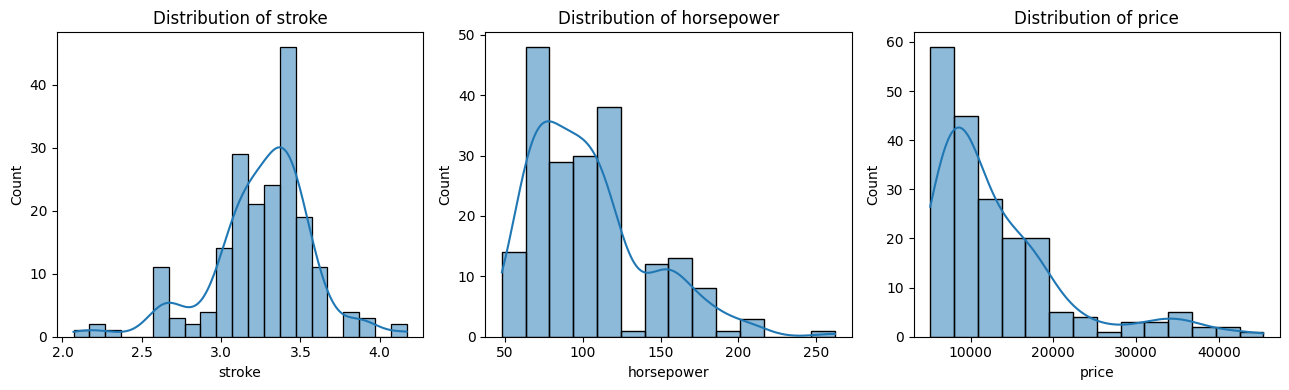

In [101]:
#Check distribution of above missing data
features = ['stroke', 'horsepower', 'price']
fig, axes = plt.subplots(1,3, figsize=(13,4))

for i, col in enumerate(features):
    sns.histplot(data=df_raw, x=col, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [102]:
#Fill missing numerical data with median since all features are skewed
for num in df_raw.select_dtypes(include=[np.number]).columns:
    df_raw[num] = df_raw[num].fillna(df_raw[num].median())
missing_numerical_count = df_raw.select_dtypes(include=[np.number]).isnull().sum()
missing_numerical_count[missing_numerical_count > 0].sort_values(ascending=False) 

Series([], dtype: int64)

In [103]:
bef_missing_count = df.isnull().sum()
af_missing_count = df_raw.isnull().sum()
print('===========================================================')
print('=                     DATA CLEANSING                      =')
print('===========================================================')
print("=== Data before Cleansing ======== Data after Cleansing === \n\n    Rows: {}, Columns: {}    |   Rows: {}, Columns: {}".format(df.shape[0], df.shape[1], df_raw.shape[0], df_raw.shape[1]))
print('===========================================================')
print('=                      MISSING DATA                       =')
print('===========================================================')
print('=== Before Cleansing ===\n')
print(bef_missing_count[bef_missing_count > 0].sort_values(ascending=False))
print('\n=== After Cleansing ===\n')
print(af_missing_count[af_missing_count > 0].sort_values(ascending=False))
print('\n===========================================================')
print('=                    DUPLICATE DATA                       =')
print('===========================================================')
print("====== before Cleansing ============ After Cleansing ====== \n\n    Duplicate Records: {}     |     Duplicate Records: {} ".format(df.duplicated().sum(),df_raw.duplicated().sum()))
print('\n===========================================================')
print('=                    UPDATED COLUMN                       =')
print('===========================================================')
print('transaction_date -> deleted\ncategorical features -> Lower Case\nEngine-Type -> renamed 1 of the value\ngas -> deleted')

=                     DATA CLEANSING                      =
=== Data before Cleansing ======== Data after Cleansing === 

    Rows: 205, Columns: 30    |   Rows: 201, Columns: 28
=                      MISSING DATA                       =
=== Before Cleansing ===

stroke               4
horsepower           3
price                3
num-of-doors         2
make                 2
transaction_date     2
horsepower-binned    1
dtype: int64

=== After Cleansing ===

Series([], dtype: int64)

=                    DUPLICATE DATA                       =
====== before Cleansing ============ After Cleansing ====== 

    Duplicate Records: 4     |     Duplicate Records: 0 

=                    UPDATED COLUMN                       =
transaction_date -> deleted
categorical features -> Lower Case
Engine-Type -> renamed 1 of the value
gas -> deleted


## Data Transformation

### Numerical Data

In [104]:
new_num_feat = df_raw.select_dtypes(include=[np.number]).columns
new_cat_feat = df_raw.select_dtypes(include=[object]).columns

scaler = MinMaxScaler()
df_raw[new_num_feat] = scaler.fit_transform(df_raw[new_num_feat])
display(df_raw[new_num_feat].head())

,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
0,0.298429,0.058309,0.413433,0.324786,0.083333,0.411171,0.260377,0.664286,0.290476,0.1250,0.294393,0.346939,0.222222,0.289474,0.207959,0.481481
1,0.298429,0.058309,0.413433,0.324786,0.083333,0.411171,0.260377,0.664286,0.290476,0.1250,0.294393,0.346939,0.222222,0.289474,0.282558,0.481481
2,0.298429,0.230321,0.449254,0.444444,0.383333,0.517843,0.343396,0.100000,0.666667,0.1250,0.495327,0.346939,0.166667,0.263158,0.282558,0.570175
3,0.518325,0.384840,0.529851,0.504274,0.541667,0.329325,0.181132,0.464286,0.633333,0.1875,0.252336,0.551020,0.305556,0.368421,0.219254,0.376157
4,0.518325,0.373178,0.529851,0.521368,0.541667,0.518231,0.283019,0.464286,0.633333,0.0625,0.313084,0.551020,0.138889,0.157895,0.306142,0.621914


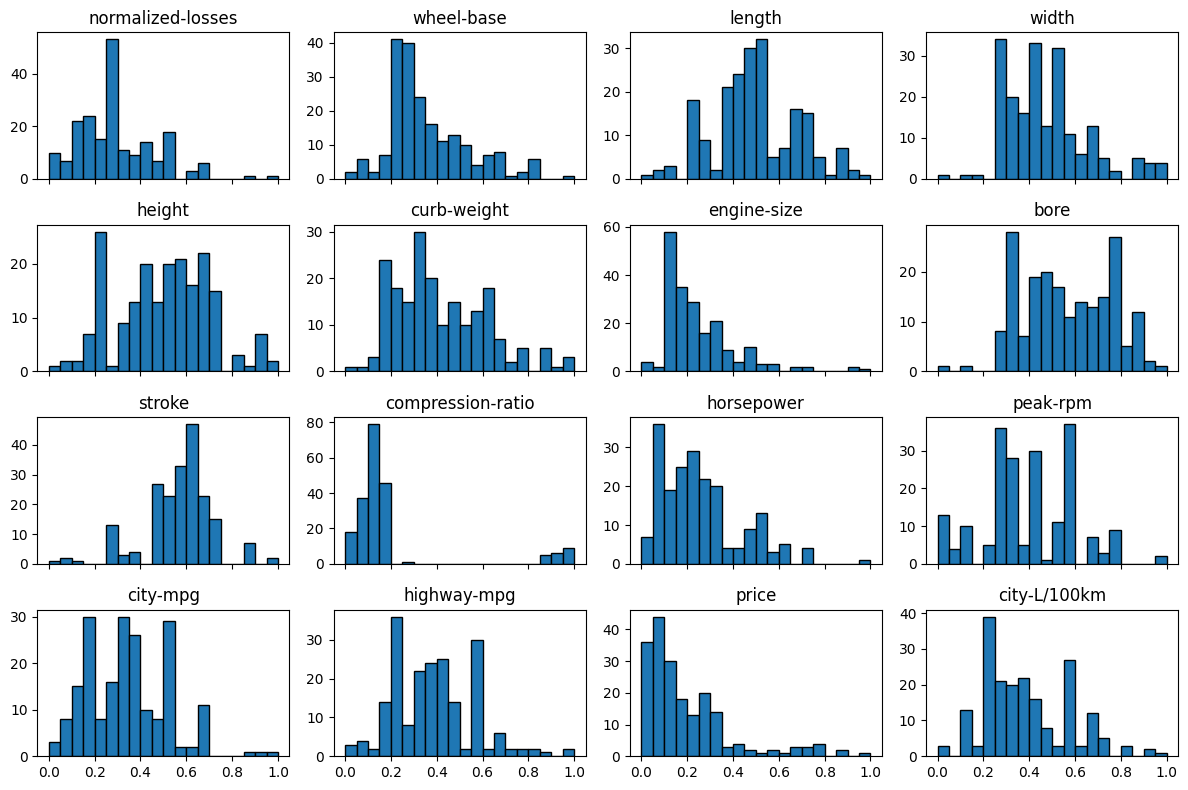

In [105]:
n_cols = 4
n_rows = int(np.ceil(len(new_num_feat) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2*n_rows), sharex=True)
axes = axes.flatten()
for i, col in enumerate(new_num_feat):
    axes[i].hist(df_raw[col], bins=20, edgecolor = 'k')
    axes[i].set_title(col)
    

plt.tight_layout()
plt.show()

### Categorical Data

In [106]:
#To define which Encode method used, first check how may unique data for each categorical features
side_by_side_unique(df_raw)

,count
make,
toyota,34
mazda,17
nissan,17
mitsubishi,12
honda,12
subaru,12
volkswagen,12
volvo,11
peugot,10


- Frequency Encoding: `make`, `fuel system`, `engine-type`, `body-style`
- Label Encoding: `num-of-cylinders`, `symboling`, `horsepower-binned`
- One Hot Encoding: `drive-wheels`, `num-of-doors`, `aspiration`, `engine-location`, `diesel`

In [107]:
freq_encoding= ['make', 'fuel-system', 'engine-type', 'body-style']
lab_encoding= ['num-of-cylinders', 'symboling', 'horsepower-binned']
oh_encoding= ['drive-wheels', 'num-of-doors', 'aspiration', 'engine-location', 'diesel']

#One Hot Encoding
df_raw = pd.get_dummies(df_raw, columns=oh_encoding, drop_first=True)

#Frequency Encoding 
for col in freq_encoding:
    freq = df_raw[col].value_counts(normalize=True)
    df_raw[col] = df_raw[col].map(freq)
    
#Label Encoding
#Mapping for Label Encoding
cylinder_map = {
    'two': 2, 'three': 3, 'four': 4, 'five': 5, 
    'six': 6, 'eight': 8, 'twelve': 12
}
horsepower_map = {'low': 0, 'medium': 1, 'high': 2}

df_raw['symboling'] = df_raw['symboling'].astype('int')

df_raw['num-of-cylinders'] = df_raw['num-of-cylinders'].map(cylinder_map)
df_raw['horsepower-binned'] = df_raw['horsepower-binned'].map(horsepower_map)
df_raw.head()

,symboling,normalized-losses,make,body-style,wheel-base,length,width,height,curb-weight,engine-type,...,price,city-L/100km,horsepower-binned,drive-wheels_awd,drive-wheels_fwd,drive-wheels_rwd,num-of-doors_two,aspiration_turbo,engine-location_rear,diesel_1
0,3,0.298429,0.014925,0.029851,0.058309,0.413433,0.324786,0.083333,0.411171,0.059701,...,0.207959,0.481481,1,False,False,True,True,False,False,False
1,3,0.298429,0.014925,0.029851,0.058309,0.413433,0.324786,0.083333,0.411171,0.059701,...,0.282558,0.481481,1,False,False,True,True,False,False,False
2,1,0.298429,0.014925,0.343284,0.230321,0.449254,0.444444,0.383333,0.517843,0.064677,...,0.282558,0.570175,1,False,False,True,True,False,False,False
3,2,0.518325,0.034826,0.467662,0.384840,0.529851,0.504274,0.541667,0.329325,0.721393,...,0.219254,0.376157,1,False,True,False,False,False,False,False
4,2,0.518325,0.034826,0.467662,0.373178,0.529851,0.521368,0.541667,0.518231,0.721393,...,0.306142,0.621914,1,False,False,False,False,False,False,False


In [108]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 0 to 200
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   symboling             201 non-null    int64  
 1   normalized-losses     201 non-null    float64
 2   make                  201 non-null    float64
 3   body-style            201 non-null    float64
 4   wheel-base            201 non-null    float64
 5   length                201 non-null    float64
 6   width                 201 non-null    float64
 7   height                201 non-null    float64
 8   curb-weight           201 non-null    float64
 9   engine-type           201 non-null    float64
 10  num-of-cylinders      201 non-null    int64  
 11  engine-size           201 non-null    float64
 12  fuel-system           201 non-null    float64
 13  bore                  201 non-null    float64
 14  stroke                201 non-null    float64
 15  compression-ratio     201 no

## Final Data

In [109]:
df_raw.to_csv('automobileEDA_processed.csv', index=False)
#'../Datasets/processed/automobileEDA_processed.csv'

## Pipeline all Process

In [110]:
freq_encoding= ['make', 'fuel-system', 'engine-type', 'body-style']
lab_encoding= ['num-of-cylinders', 'symboling', 'horsepower-binned']
oh_encoding= ['drive-wheels', 'num-of-doors', 'aspiration', 'engine-location', 'diesel']
scaler = MinMaxScaler()

#Read Data
def read_data(data):
    df = pd.read_csv('../Datasets/raw/automobileEDA_dirty_training.csv')
    print(f"Number of Records: {df.shape[0]}")
    print(f"Number of Features: {df.shape[1]}")
    missing_count = df.isnull().sum()
    print("\nNumber of missing values in each feature:")
    print("Number of duplicate records: ", df.duplicated().sum())
    display(missing_count[missing_count > 0].sort_values(ascending=False))
    print('\nData that need to be reformed the format (Date & Case)')
    display(df[['transaction_date', 'make']].head(5))
    return df

read_data(df)

Number of Records: 205
Number of Features: 30

Number of missing values in each feature:
Number of duplicate records:  4


stroke               4
horsepower           3
price                3
num-of-doors         2
make                 2
transaction_date     2
horsepower-binned    1
dtype: int64


Data that need to be reformed the format (Date & Case)


,transaction_date,make
0,2025-01-01,alfa-romero
1,02/01/2025,alfa-romero
2,01-03-2025,ALFA-ROMERO
3,04-Jan-2025,audi
4,2025-01-05,audi


,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,01-03-2025,1,122,ALFA-ROMERO,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,04-Jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,2025-07-20,-1,95,volvo,turbo,four,sedan,rwd,front,109.1,...,9.5,114.0,5400.0,19,25,22625.0,12.368421,Medium,0,1
201,06/01/2025,2,122,audi,std,two,sedan,fwd,front,99.8,...,8.5,110.0,5500.0,19,25,15250.0,12.368421,Medium,0,1
202,26/01/2025,1,148,dodge,std,four,sedan,fwd,front,93.7,...,9.4,68.0,5500.0,31,38,7609.0,7.580645,Low,0,1
203,2025-03-02,0,122,mazda,std,four,sedan,fwd,front,98.8,...,22.7,64.0,4650.0,36,42,10795.0,6.527778,Low,1,0


In [111]:
df[['transaction_date', 'make']].head(5)

,transaction_date,make
0,2025-01-01,alfa-romero
1,02/01/2025,alfa-romero
2,01-03-2025,ALFA-ROMERO
3,04-Jan-2025,audi
4,2025-01-05,audi
